### Libs

In [16]:
# Sys, OS and generals
import os
from os.path import join as pjoin
import sys
import json
import re
import glob
from typing import Dict, List, TypedDict, Tuple
from dotenv import load_dotenv
load_dotenv(dotenv_path="../.env")

# AI and math
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from plotly.subplots import make_subplots
import numpy as np
import torch
import kennard_stone as ks
import trimesh
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Shape model and LoRA
# Add the cloned 'shape' repo folder to your python path
from shape_foundation.configs.default import load_config
from shape_foundation.configs.default import ShapeConfig
from shape_foundation.models.gaot_backbone import GAOTBackbone
from shape_foundation.data.preprocessing import MeshPreprocessor
from shape_foundation.data.sampling import SurfaceSampler
from shape_foundation.training.losses import LossComputer, compute_raw_geo_stats_dim
from peft import PeftModel

### Importing Model

In [5]:
LOCAL_DIR = pjoin("checkpoints/shape-fm-small-v3")
METADATA_DIR = pjoin("..","pump_metadata")
LORA_DIR = pjoin("..", "lora_checkpoints", "final_adapter")

In [6]:
config_yaml = pjoin(LOCAL_DIR, "small.yaml")
checkpoint_pt = pjoin(LOCAL_DIR, "checkpoint_final.pt")
print("Loading configuration...")
config = load_config(config_yaml)
# Bypass torch-cluster requirement using native PyTorch fallback search
config.tokenizer.neighbor.backend = "native"
# Setup device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GAOTBackbone(config).to(device)
print(f"Loading checkpoint weights onto {device}...")
checkpoint = torch.load(checkpoint_pt, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
# LoRA model
model = PeftModel.from_pretrained(model, LORA_DIR)

Loading configuration...
Loading checkpoint weights onto cuda...


In [7]:
model.eval()
# Initialize mesh processors
preprocessor = MeshPreprocessor(config.input)
sampler = SurfaceSampler(config.input)
print("Model ready!")

Model ready!


#### Available Pump STL files

In [9]:
def collect_stl_files_walk(folder_path='.'):
    """Returns a list of full file paths for all .stl files."""
    stl_files = []
    samples = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith('.stl'):
                stl_files.append(pjoin(root, file))
                samples.append(root.split("/")[-1])
    return stl_files, samples

stl_files, samples = collect_stl_files_walk(METADATA_DIR)

In [10]:
# selected_folders = ['sample_000019',
#                     'sample_000022',
#                     'sample_000063',
#                     'sample_000107',
#                     'sample_000132']

selected_folders = samples[::10]


## Eval Model

###  Loading meshes

In [11]:
mesh_dict = {}
for folder in selected_folders:
    stl_path = pjoin(METADATA_DIR, folder, "merged_surfaces.stl")
    mesh = trimesh.load(stl_path)
    if isinstance(mesh, trimesh.Scene):
        mesh = mesh.dump(concatenate=True)
    mesh_dict[folder] = mesh

### Check similarity between embeddings of different geometries

In [13]:
def preprocess_sample_and_build_features(preprocessor: MeshPreprocessor, sampler: SurfaceSampler, mesh:trimesh.Trimesh):
    vertices = mesh.vertices
    faces = mesh.faces

    # Preprocess mesh (canonicalization, normals, Laplacian curvature)
    preprocessed = preprocessor(vertices, faces)
    # Subsample surface points
    sampled = sampler.sample(
        vertices=preprocessed["vertices"],
        faces=preprocessed["faces"],
        normals=preprocessed["normals"],
        curvature=preprocessed["curvature"]
    )
    
    # Build node features
    features = preprocessor.build_features(
        points=sampled["points"],
        normals=sampled["normals"],
        curvature=sampled["curvature"]
    )
    return preprocessed, sampled, features

def extract_points_features_normals_curvature_tensors(sampled, features) -> Tuple[torch.TensorType, ...]:
    points_t = torch.from_numpy(sampled["points"]).unsqueeze(0).to(device)
    features_t = torch.from_numpy(features).unsqueeze(0).to(device)
    normals_t = torch.from_numpy(sampled["normals"]).unsqueeze(0).to(device) if sampled["normals"] is not None else None
    curvature_t = torch.from_numpy(sampled["curvature"]).unsqueeze(0).to(device) if sampled["curvature"] is not None else None
    return points_t, features_t, normals_t, curvature_t

In [14]:
def forward_pool_embedding_from_mesh(mesh: trimesh.Trimesh, preprocessor: MeshPreprocessor, sampler:SurfaceSampler):
    preprocessed, sampled, features = preprocess_sample_and_build_features(preprocessor=preprocessor, sampler=sampler,mesh=mesh) 
    # Convert to model-ready PyTorch Tensors
    points_t, features_t, normals_t, curvature_t = extract_points_features_normals_curvature_tensors(sampled, features)
    # Run forward pass to extract shape embedding
    with torch.no_grad():
        output = model.forward_tokens(
            points=points_t,
            features=features_t,
            normals=normals_t,
            curvature=curvature_t
        )
        # The pooled global embedding vector (dim=256 for small model)
        pooled_emb = output["pooled_embedding"].cpu().numpy().flatten()
    return pooled_emb
        

In [ ]:
# 2. Iterate over selected_folders and run inference
embeddings_dict = {}
for folder, mesh in mesh_dict.items():
    print(f"Processing {folder}...")
    try:
        pooled_emb = forward_pool_embedding_from_mesh(mesh, preprocessor, sampler) 
        embeddings_dict[folder] = pooled_emb
        print(f"Successfully encoded {folder}! Embedding vector shape: {pooled_emb.shape}")
        
    except Exception as e:
        print(f"Error encoding {folder}: {e}")
print("\nTesting complete!")

Processing sample_004855...
Successfully encoded sample_004855! Embedding vector shape: (128,)
Processing sample_004743...
Successfully encoded sample_004743! Embedding vector shape: (128,)
Processing sample_002276...
Successfully encoded sample_002276! Embedding vector shape: (128,)
Processing sample_003287...
Successfully encoded sample_003287! Embedding vector shape: (128,)
Processing sample_002088...
Successfully encoded sample_002088! Embedding vector shape: (128,)
Processing sample_000444...
Successfully encoded sample_000444! Embedding vector shape: (128,)
Processing sample_001953...
Successfully encoded sample_001953! Embedding vector shape: (128,)
Processing sample_000816...
Successfully encoded sample_000816! Embedding vector shape: (128,)
Processing sample_003959...
Successfully encoded sample_003959! Embedding vector shape: (128,)
Processing sample_002964...
Successfully encoded sample_002964! Embedding vector shape: (128,)
Processing sample_001064...
Successfully encoded s

In [12]:
cos_matrix = torch.eye(len(selected_folders))
for i, emb_k1 in enumerate(selected_folders[:]):
    for j, emb_k2 in enumerate(selected_folders[i+1:], i+1):
        emb1 = torch.from_numpy(embeddings_dict[emb_k1])
        emb2 = torch.from_numpy(embeddings_dict[emb_k2])
        cos = torch.dot(emb1, emb2)/(torch.linalg.norm(emb1)*torch.linalg.norm(emb2))
        cos_matrix[i,j], cos_matrix[j,i] = cos, cos 

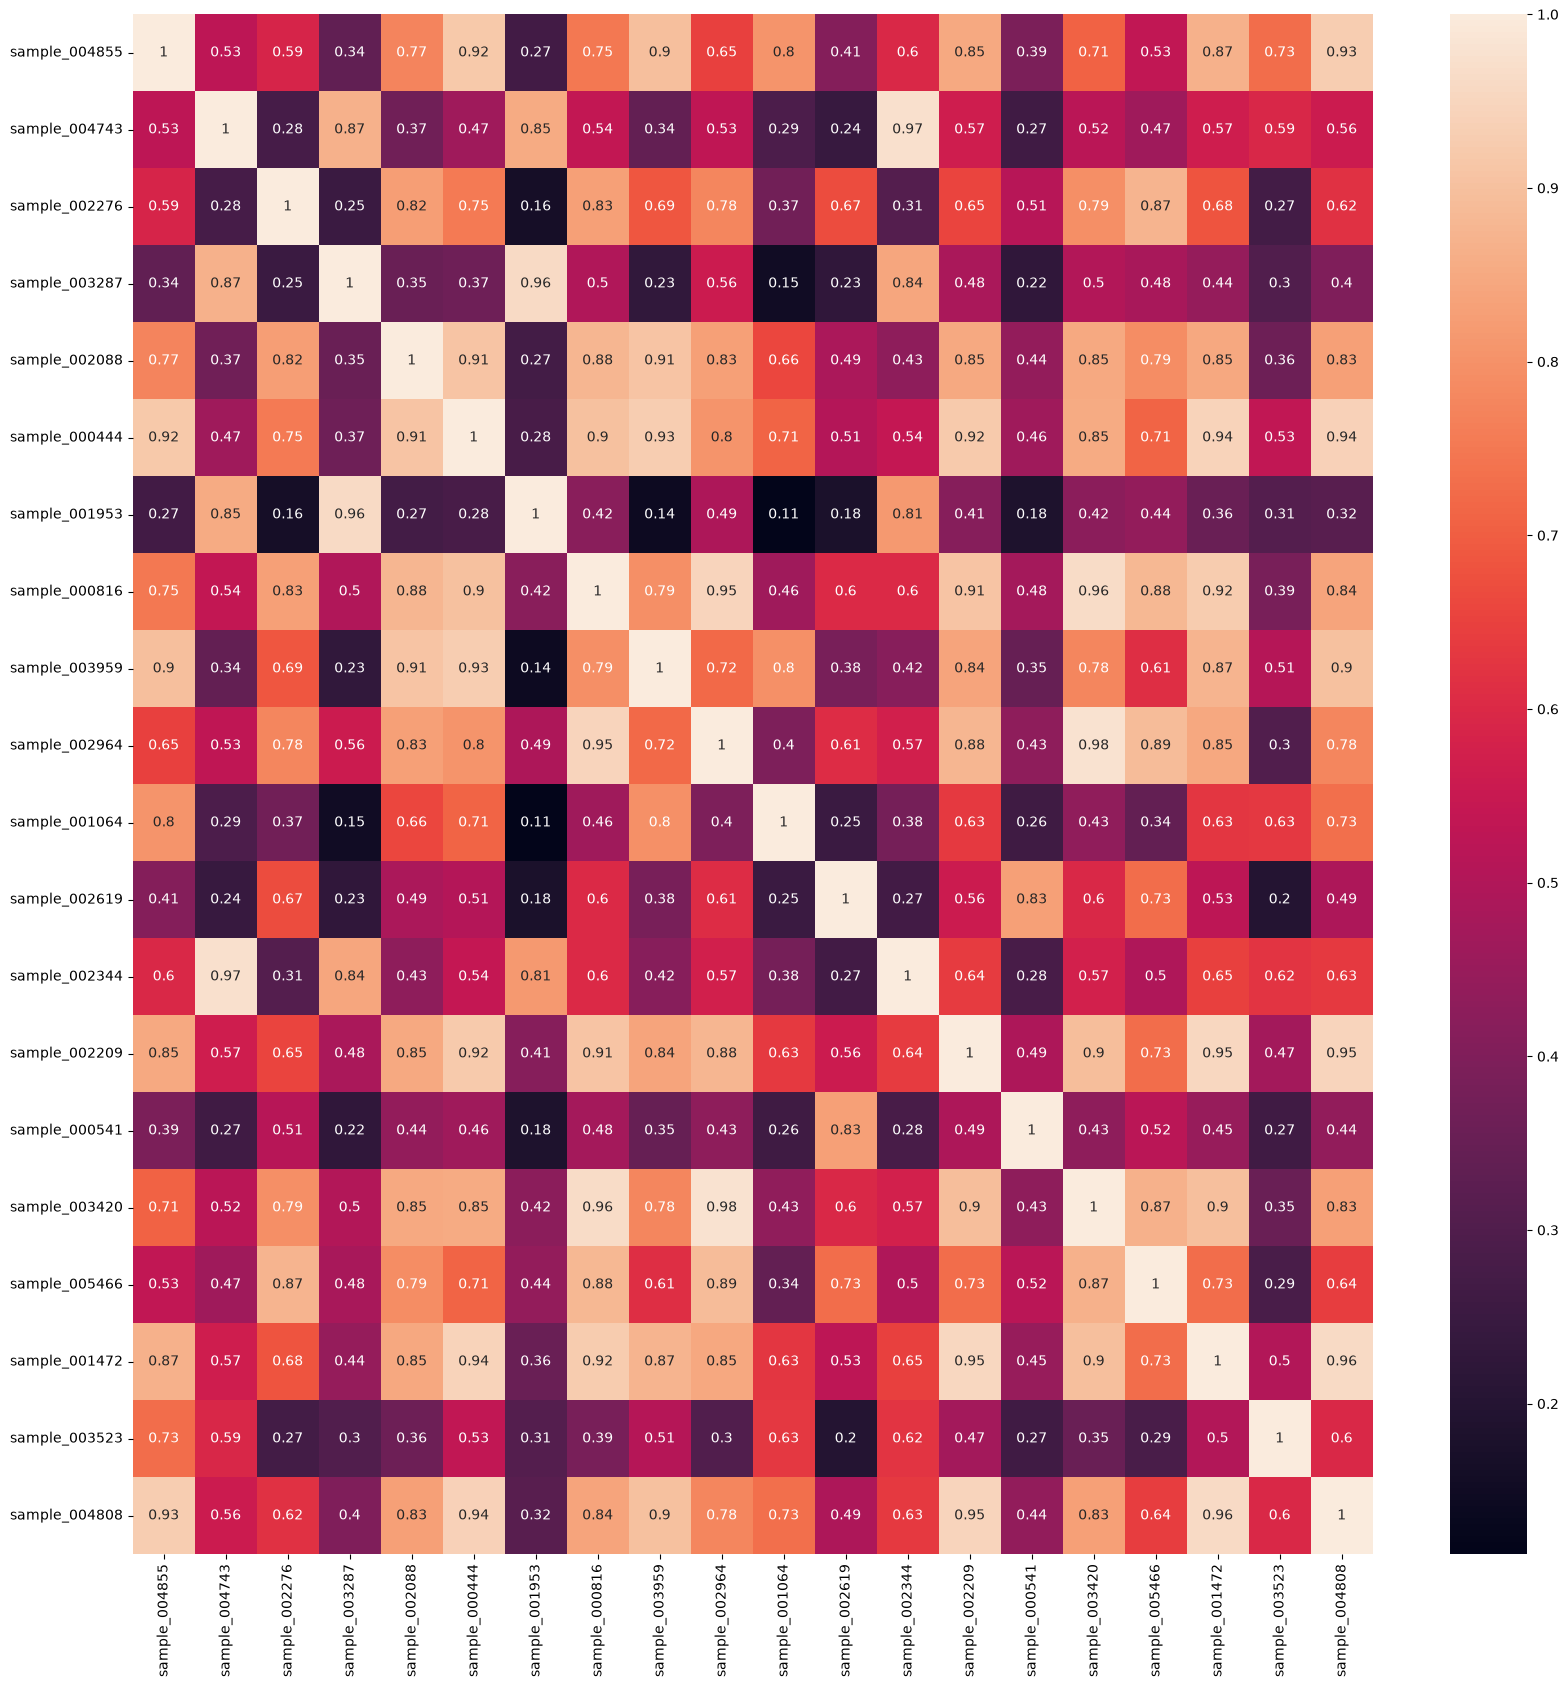

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(data=cos_matrix, xticklabels=selected_folders, yticklabels=selected_folders, annot=True)
plt.show()

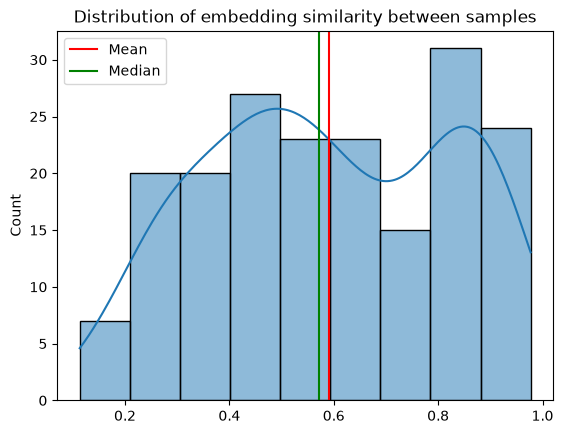

In [14]:
corrs_flat = torch.tril(cos_matrix, diagonal=-1)
corrs_flat = corrs_flat.flatten()
corrs_flat = corrs_flat[corrs_flat!=0]
mean, median = corrs_flat.mean(), corrs_flat.median()
sns.histplot(corrs_flat, kde=True)
plt.axvline(x=mean, color="red", label="Mean")
plt.axvline(x=median, color="green", label="Median")
plt.title("Distribution of embedding similarity between samples")
plt.legend()
plt.show()

## Evaluate recontruction
Since reconstruction is already Z-Normalized, MAPE isn't a good choice, so here we priorize $R^2, MSE, MAE$

In [59]:
int vec
def evaluate_mesh_reconstruction(mesh_dict: Dict[str, trimesh.Trimesh], model, checkpoint, config, device, mask_ratio=0.5):
    """
    Given a STL Dict, calculates reconstruction MSE and R2 scores.
    Args:
        mesh_dict: Dict of STL meshes.
        model: Loaded GAOTBackbone model.
        checkpoint: The loaded checkpoint dictionary.
        config: Loaded config object.
        device: PyTorch device ('cuda' or 'cpu').
        mask_ratio: Fraction of geometry to mask (0.0 for full reconstruction, 0.5 for infilling).
    """
    # 1. Initialize LossComputer to get the recon projection head & calibration buffers
    recon_dim = compute_raw_geo_stats_dim(config.tokenizer.geo_embed)
    loss_computer = LossComputer(
        config.train.loss,
        token_dim=config.tokenizer.latent.token_dim,
        recon_target_dim=recon_dim
    ).to(device)
    
    if "loss_computer_state_dict" in checkpoint:
        loss_computer.load_state_dict(checkpoint["loss_computer_state_dict"], strict=False)
    loss_computer.eval()
    model.eval()
    
    # 2. Initialize preprocessing tools
    preprocessor = MeshPreprocessor(config.input)
    sampler = SurfaceSampler(config.input)
    
    results = {}
    
    for sample, mesh in mesh_dict.items():
        try:
            # Preprocess and sample
            preprocessed, sampled, features = preprocess_sample_and_build_features(preprocessor, sampler, mesh)
            points_t, features_t, normals_t, curvature_t = extract_points_features_normals_curvature_tensors(features=features, sampled=sampled)
            # 3. Create evaluation mask (if mask_ratio > 0)
            B, T = points_t.shape[0], model.encoder.num_tokens
            mask = None
            if mask_ratio > 0.0:
                n_mask = int(T * mask_ratio)
                mask = torch.zeros(B, T, dtype=torch.bool, device=device)
                mask[0, torch.randperm(T)[:n_mask]] = True
            
            # 4. Model forward pass
            with torch.no_grad():
                output = model.forward_tokens(
                    points=points_t,
                    features=features_t,
                    normals=normals_t,
                    curvature=curvature_t,
                    mask=mask
                )
                
                # Get the real targets and predict the reconstructed stats
                target_raw = output["raw_geo_stats"]
                # Z-score normalize targets (uses calibration buffers from training)
                target_norm = loss_computer._maybe_normalize_target(target_raw)
                predicted_norm = loss_computer.recon_proj(output["token_embeddings"])
                
                # If masked, only evaluate on the unseen masked parts
                if mask is not None:
                    eval_pred = predicted_norm[mask]
                    eval_tgt = target_norm[mask]
                else:
                    eval_pred = predicted_norm
                    eval_tgt = target_norm
                
                # 5. Compute metrics
                mean_tgt = torch.mean(eval_tgt)
                median_tgt = torch.median(eval_tgt)
                min_tgt, max_tgt = torch.min(eval_tgt), torch.max(eval_tgt)
                mse = torch.mean((eval_pred - eval_tgt) ** 2).item()
                mae = torch.mean(torch.abs((eval_pred - eval_tgt)))
                
                # R2 (Coefficient of Determination)
                ss_res = torch.sum((eval_pred - eval_tgt) ** 2).item()
                ss_tot = torch.sum((eval_tgt - torch.mean(eval_tgt)) ** 2).item()
                r2 = 1.0 - (ss_res / (ss_tot + 1e-12))
                
            results[sample] = {"mse": mse, "r2": r2}
            # sns.histplot(eval_tgt.mean(axis=[0,1]).flatten().cpu(), kde=True, )
            print(f"Mesh: {os.path.basename(sample)}")
            print(f"Target mesh: Mean : {mean_tgt}, Median {median_tgt}, Min/Max{min_tgt}/{max_tgt}")
            print(f"  -> Reconstruction MAE (lower is better): {mae:.5f}")
            print(f"  -> Reconstruction MSE (lower is better): {mse:.5f}")
            print(f"  -> Reconstruction R² Score (close to 1.0 is better): {r2:.3f}\n")
            
        except Exception as e:
            print(f"Error processing {sample}: {e}\n")
            
    return results

In [48]:
# Run full autoencoder reconstruction evaluation (0% mask)
print("--- RUNNING 0% MASK AUTOENCODER EVALUATION ---")
ae_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.0
)

# Run standard infilling evaluation (50% mask)
print("--- RUNNING 50% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.5
)

print("--- RUNNING 25% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.25
)

print("--- RUNNING 80% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.8
)


--- RUNNING 0% MASK AUTOENCODER EVALUATION ---
Mesh: sample_004855
Target mesh: Mean : -0.03536952659487724, Median -0.01597297191619873, Min/Max-5.105794906616211/5.417849540710449
  -> Reconstruction MAE (lower is better): 1.34074
  -> Reconstruction MSE (lower is better): 0.04036
  -> Reconstruction R² Score (close to 1.0 is better): 0.942

Mesh: sample_004743
Target mesh: Mean : -0.03894346207380295, Median -0.01597297191619873, Min/Max-5.34012508392334/5.415882587432861
  -> Reconstruction MAE (lower is better): 1.17220
  -> Reconstruction MSE (lower is better): 0.03681
  -> Reconstruction R² Score (close to 1.0 is better): 0.946

Mesh: sample_002276
Target mesh: Mean : -0.03791341930627823, Median -0.01597297191619873, Min/Max-5.117221355438232/5.129710674285889
  -> Reconstruction MAE (lower is better): 1.18340
  -> Reconstruction MSE (lower is better): 0.03854
  -> Reconstruction R² Score (close to 1.0 is better): 0.944

Mesh: sample_003287
Target mesh: Mean : -0.04293234646320

KeyboardInterrupt: 

## 3D Visualizations

In [25]:
embeddings_dict = np.load("embeddings_dict.npy", allow_pickle=True).item()
preprocessed, sampled, features = preprocess_sample_and_build_features(mesh=mesh_dict["sample_000444"], preprocessor=preprocessor, sampler=sampler)

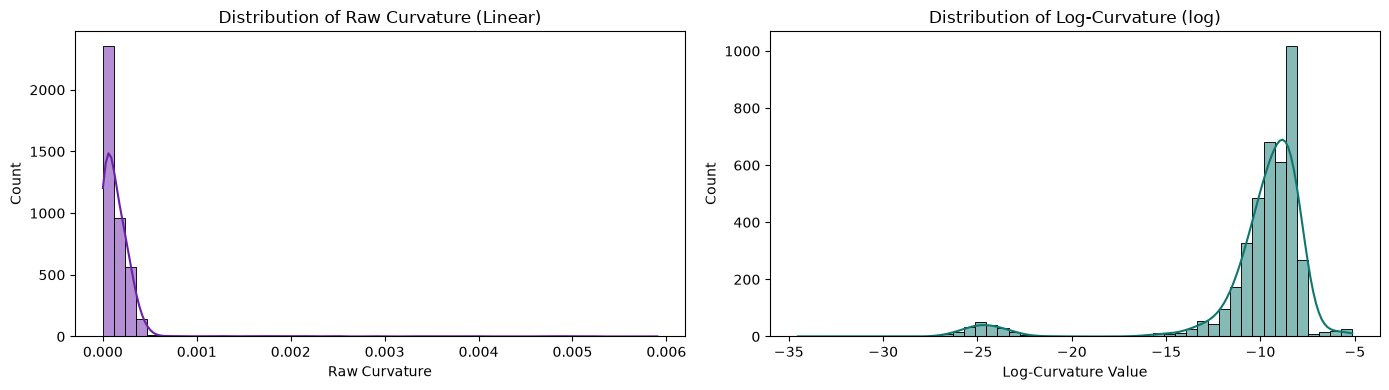

In [24]:
# 1. Get points and curvature data
pts = sampled["points"]        # Shape: (8192, 3)
curvs = sampled["curvature"].flatten() if sampled["curvature"] is not None else np.zeros(len(pts))

# Apply log transform
curvs_log = np.log(curvs)

# 2. Render Side-by-Side 3D Point Clouds in Plotly
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=("Linear Curvature Scale", "Log Curvature Scale (log1p)")
)

# Left: Linear Scale Plot
fig.add_trace(
    go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=curvs,
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title="Linear", x=0.45)
        )
    ),
    row=1, col=1
)

# Right: Log Scale Plot
fig.add_trace(
    go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=curvs_log,
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title="Log(1+x)", x=1.0)
        )
    ),
    row=1, col=2
)

# Clean up layout and turn off default background grid lines
fig.update_layout(
    title_text="3D Geometry View: Linear vs. Log Curvature Mapping",
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False)),
    scene2=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False)),
    margin=dict(l=0, r=0, b=0, t=80)
)
fig.show()

# 3. Plot Side-by-Side Histograms (Seaborn)
fig_hist, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Raw Curvature Distribution
sns.histplot(curvs, ax=axes[0], bins=50, color='#6b21a8', kde=True)
axes[0].set_title("Distribution of Raw Curvature (Linear)")
axes[0].set_xlabel("Raw Curvature")
axes[0].set_ylabel("Count")

# Right: Log-Curvature Distribution
sns.histplot(curvs_log, ax=axes[1], bins=50, color='#0f766e', kde=True)
axes[1].set_title("Distribution of Log-Curvature (log)")
axes[1].set_xlabel("Log-Curvature Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


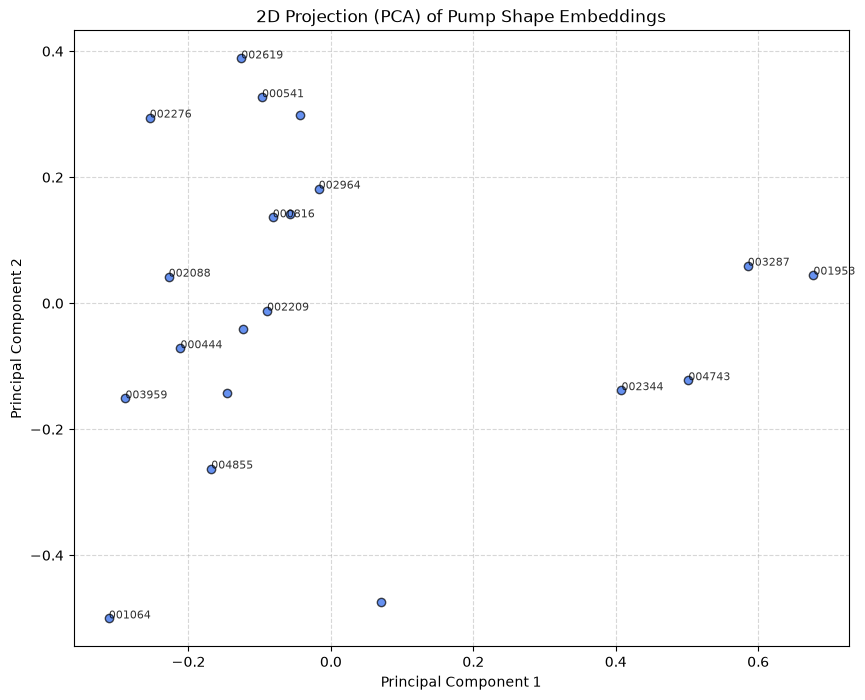

In [25]:
folders = list(embeddings_dict.keys())
embeddings = np.array(list(embeddings_dict.values()))

# 2. Reduce to 2D using PCA
pca = PCA(n_components=3)
coords = pca.fit_transform(embeddings)

# 3. Plot
plt.figure(figsize=(10, 8), dpi=100)
plt.scatter(coords[:, 0], coords[:, 1], c='#2563eb', alpha=0.7, edgecolors='black')

# Annotate some points to identify them
for i, folder in enumerate(folders[:15]): # annotate first 15 pumps
    plt.annotate(folder.split("_")[-1], (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.8)

plt.title("2D Projection (PCA) of Pump Shape Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [40]:
# 1. Load your saved embeddings dictionary (e.g. diverse_pump_embeddings.npy)
# Replace the path with the location of your npy file
# embeddings_dict = np.load("diverse_pump_embeddings.npy", allow_pickle=True).item()

folders = list(embeddings_dict.keys())
embeddings = np.array(list(embeddings_dict.values()))

# 2. Reduce the 256-dimensional embeddings to 3 dimensions using PCA
pca = PCA(n_components=3)
pca_coords_3d = pca.fit_transform(embeddings)

# Calculate the variance explained by the first 3 components
explained_var = pca.explained_variance_ratio_ * 100
print(f"Explained Variance: PC1={explained_var[0]:.2f}%, PC2={explained_var[1]:.2f}%, PC3={explained_var[2]:.2f}%")

# 3. Create an interactive 3D Scatter plot using Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=pca_coords_3d[:, 0],
    y=pca_coords_3d[:, 1],
    z=pca_coords_3d[:, 2],
    mode='markers+text',
    marker=dict(
        size=5,
        color=pca_coords_3d[:, 2], # Color by the 3rd principal component
        colorscale='Viridis',
        opacity=0.8,
        line=dict(color='black', width=1)
    ),
    text=[f.split("_")[-1] for f in folders],  # Display only the sample number (e.g., 001469)
    hoverinfo='text'
)])

# Update plot layout and axis labels
fig.update_layout(
    title="3D PCA Projection of Pump Shape Embeddings",
    scene=dict(
        xaxis=dict(title=f"PC1 ({explained_var[0]:.1f}%)"),
        yaxis=dict(title=f"PC2 ({explained_var[1]:.1f}%)"),
        zaxis=dict(title=f"PC3 ({explained_var[2]:.1f}%)")
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


Explained Variance: PC1=37.96%, PC2=25.82%, PC3=14.66%


In [41]:
# Extract the first two principal components (PC1 and PC2)
# There is zero difference between doing this and fitting PCA with n_components=2
pca_coords_2d = pca_coords_3d[:, :2] 

# Plot the 2D PCA
fig = go.Figure(data=[go.Scatter(
    x=pca_coords_2d[:, 0],
    y=pca_coords_2d[:, 1],
    mode='markers+text',
    marker=dict(
        size=8,
        color=pca_coords_2d[:, 1],
        colorscale='Viridis',
        line=dict(color='black', width=1)
    ),
    text=[f.split("_")[-1] for f in folders],
    hoverinfo='text'
)])

fig.update_layout(
    title="2D PCA Projection (Sliced from 3D PCA)",
    xaxis=dict(title=f"PC1 ({explained_var[0]:.1f}%)"),
    yaxis=dict(title=f"PC2 ({explained_var[1]:.1f}%)"),
    template="plotly_white"
)
fig.show()


In [ ]:
# 1. Load the embeddings dictionary
# embeddings_dict = np.load("diverse_pump_embeddings.npy", allow_pickle=True).item()
folders = list(embeddings_dict.keys())
embeddings = np.array(list(embeddings_dict.values()))

# 2. Fit UMAP to reduce the embeddings to 3 dimensions
reducer = umap.UMAP(
    n_components=3, 
    n_neighbors=15,    # Controls local vs. global balance (default: 15)
    min_dist=0.1,      # Controls how tightly points are grouped (default: 0.1)
    random_state=42    # Ensures reproducible projections
)
umap_coords_3d = reducer.fit_transform(embeddings)

# 3. Create the interactive 3D UMAP plot using Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=umap_coords_3d[:, 0],
    y=umap_coords_3d[:, 1],
    z=umap_coords_3d[:, 2],
    mode='markers+text',
    marker=dict(
        size=5,
        color=umap_coords_3d[:, 2], # Color by the UMAP Z-axis
        colorscale='Viridis',
        opacity=0.8,
        line=dict(color='black', width=1)
    ),
    text=[f.split("_")[-1] for f in folders],  # Display only the sample number
    hoverinfo='text'
)])

fig.update_layout(
    title="3D UMAP Projection of Pump Shape Embeddings",
    scene=dict(
        xaxis=dict(title="UMAP Dimension 1"),
        yaxis=dict(title="UMAP Dimension 2"),
        zaxis=dict(title="UMAP Dimension 3")
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


/home/vpspepe/Documents/TUD/HiWi/EcoTwin/POC_Tests/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# Assuming 'coords_3d' is already calculated from your 3D cell:
umap_coords_2d = umap_coords_3d[:, :2]  # Extract only the first two columns (X and Y)

# Create the 2D plot using the sliced coordinates
fig = go.Figure(data=[go.Scatter(
    x=umap_coords_2d[:, 0],
    y=umap_coords_2d[:, 1],
    mode='markers+text',
    marker=dict(
        size=8,
        color=umap_coords_2d[:, 1],
        colorscale='Viridis',
        line=dict(color='black', width=1)
    ),
    text=[f.split("_")[-1] for f in folders],
    hoverinfo='text'
)])

fig.update_layout(
    title="2D UMAP (Sliced from 3D Projection)",
    xaxis=dict(title="UMAP Dimension 1"),
    yaxis=dict(title="UMAP Dimension 2"),
    template="plotly_white"
)
fig.show()


## Our 3D Pump

In [26]:
pump_mesh_path = pjoin("..","..","PumpStaticROM","data", "raw", "merged_stls", "3DPump_FirstRun_surface.stl")
pump_mesh = trimesh.load_mesh(pump_mesh_path)
ecotwin_pump_mesh_dict = {"ecotwin": pump_mesh}

In [60]:
# Run full autoencoder reconstruction evaluation (0% mask)
print("--- RUNNING 0% MASK AUTOENCODER EVALUATION ---")
ae_results = evaluate_mesh_reconstruction(
    ecotwin_pump_mesh_dict, model, checkpoint, config, device, mask_ratio=0.0
)

# Run standard infilling evaluation (50% mask)
print("--- RUNNING 50% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    ecotwin_pump_mesh_dict, model, checkpoint, config, device, mask_ratio=0.5
)

print("--- RUNNING 25% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    ecotwin_pump_mesh_dict, model, checkpoint, config, device, mask_ratio=0.25
)

print("--- RUNNING 40% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    ecotwin_pump_mesh_dict, model, checkpoint, config, device, mask_ratio=0.4
)


--- RUNNING 0% MASK AUTOENCODER EVALUATION ---
Mesh: ecotwin
Target mesh: Mean : -0.025575555860996246, Median -0.01597297191619873, Min/Max-5.302572727203369/5.877888202667236
  -> Reconstruction MAE (lower is better): 0.04391
  -> Reconstruction MSE (lower is better): 0.02922
  -> Reconstruction R² Score (close to 1.0 is better): 0.961

--- RUNNING 50% MASK INFILL EVALUATION ---
Mesh: ecotwin
Target mesh: Mean : -0.024948103353381157, Median -0.01597297191619873, Min/Max-5.302574157714844/5.747060775756836
  -> Reconstruction MAE (lower is better): 0.27171
  -> Reconstruction MSE (lower is better): 0.45567
  -> Reconstruction R² Score (close to 1.0 is better): 0.393

--- RUNNING 25% MASK INFILL EVALUATION ---
Mesh: ecotwin
Target mesh: Mean : -0.027167491614818573, Median -0.01597297191619873, Min/Max-5.302572727203369/5.762968063354492
  -> Reconstruction MAE (lower is better): 0.04464
  -> Reconstruction MSE (lower is better): 0.03238
  -> Reconstruction R² Score (close to 1.0 is b

In [28]:
ecotwin_emb = forward_pool_embedding_from_mesh(pump_mesh, preprocessor, sampler)

In [29]:
ecotwin_emb = torch.from_numpy(ecotwin_emb)

In [30]:
emb_stacked = torch.from_numpy(np.vstack(list(embeddings_dict.values())))

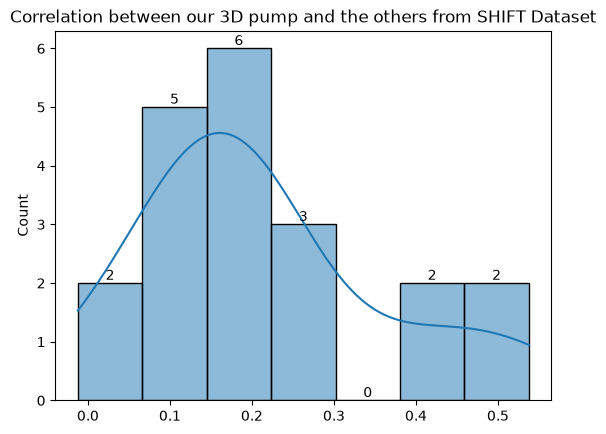

In [40]:
dots = (emb_stacked @ (ecotwin_emb.reshape((-1,1)))).flatten()
# norms = torch.linalg.norm(emb_stacked, axis=1)*torch.linalg.norm(ecotwin_emb)
norms = torch.linalg.norm(emb_stacked, axis=1)*torch.linalg.norm(ecotwin_emb)
cos_vals = dots/norms
ax = sns.histplot(cos_vals, kde=True)
ax.set(title="Correlation between our 3D pump and the others from SHIFT Dataset",)
ax.bar_label(ax.containers[0])
plt.show()

In [65]:
dots = ecotwin_emb.reshape(1,-1) @ (ecotwin_emb.reshape((-1,1))).flatten()
# norms = torch.linalg.norm(emb_stacked, axis=1)*torch.linalg.norm(ecotwin_emb)
norms = torch.linalg.norm(ecotwin_emb)*torch.linalg.norm(ecotwin_emb)
dots/norms

tensor([1.0000])

In [58]:
ecotwin_emb.shape

torch.Size([128])